In [1]:
!pip install -q shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import shap
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42


In [2]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
import os

dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['jannatulferdaues']


In [4]:
import os

dataset_path = "/kaggle/input/datasets/jannatulferdaues"

print(os.listdir(dataset_path))

['ghdi-student-dataset']


In [5]:
import os

dataset_path = "/kaggle/input/datasets/jannatulferdaues/ghdi-student-dataset"

print(os.listdir(dataset_path))

['student_dataset.xlsx']


In [6]:
DATA_PATH = "/kaggle/input/datasets/jannatulferdaues/ghdi-student-dataset/student_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

# Drop the stray "Unnamed: 0" index column that Excel exports sometimes carry
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Shape:", df.shape)
df.head()

Shape: (55000, 11)


,Country,University,Country_HDI,Country_Life_Expectancy,Education_Level,Field_of_Study,Language_Proficiency,Health_Quality_Score_1to5,Stress_Level_1to5,Monthly_Earnings_Savings_USD,Readiness_Score_0to100
0,Afghanistan,Afghan University,0.498,57.950001,Master's,Natural Sciences,Native/Fluent,2,2,1316.37,61
1,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Education,Native/Fluent,2,4,1892.79,70
2,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Social Sciences & Psychology,Native/Fluent,2,4,2030.31,69
3,Afghanistan,Afghan University,0.498,57.950001,Undergraduate,Engineering & Technology,Native/Fluent,3,2,1646.31,64
4,Afghanistan,Afghan University,0.498,57.950001,Master's,"Arts, Humanities & Design",Beginner (A1-A2),2,3,1299.43,52


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       55000 non-null  object 
 1   University                    55000 non-null  object 
 2   Country_HDI                   55000 non-null  float64
 3   Country_Life_Expectancy       55000 non-null  float64
 4   Education_Level               55000 non-null  object 
 5   Field_of_Study                55000 non-null  object 
 6   Language_Proficiency          55000 non-null  object 
 7   Health_Quality_Score_1to5     55000 non-null  int64  
 8   Stress_Level_1to5             55000 non-null  int64  
 9   Monthly_Earnings_Savings_USD  55000 non-null  float64
 10  Readiness_Score_0to100        55000 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 4.6+ MB


In [8]:
df.describe()

,Country_HDI,Country_Life_Expectancy,Health_Quality_Score_1to5,Stress_Level_1to5,Monthly_Earnings_Savings_USD,Readiness_Score_0to100
count,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,0.715645,72.803022,3.559945,2.972873,1873.841880,65.492236
std,0.155013,7.395078,1.138753,1.031685,606.134564,10.113286
min,0.354000,50.160000,1.000000,1.000000,50.000000,28.000000
25%,0.591000,67.339996,3.000000,2.000000,1465.117500,58.000000
50%,0.747000,74.580002,4.000000,3.000000,1885.790000,66.000000
75%,0.838000,78.260002,4.000000,4.000000,2289.947500,73.000000
max,0.953000,83.940002,5.000000,5.000000,4422.740000,97.000000


#  Check for missing values and duplicates

In [9]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Country                         0
University                      0
Country_HDI                     0
Country_Life_Expectancy         0
Education_Level                 0
Field_of_Study                  0
Language_Proficiency            0
Health_Quality_Score_1to5       0
Stress_Level_1to5               0
Monthly_Earnings_Savings_USD    0
Readiness_Score_0to100          0
dtype: int64

Duplicate rows: 0


#  Visualization

## 1. Target distribution


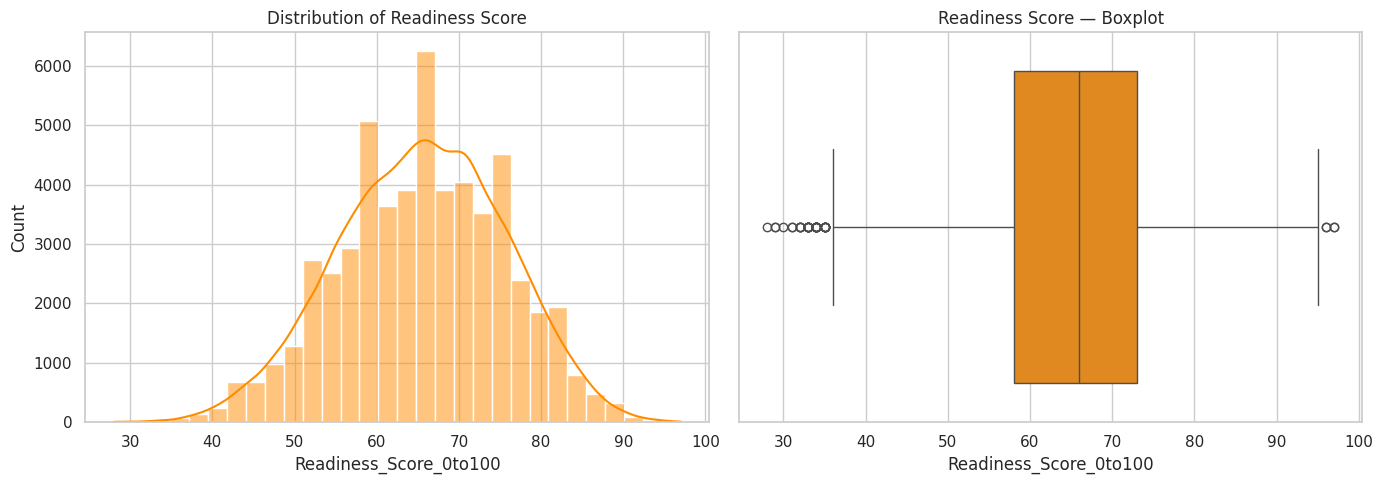

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Readiness_Score_0to100"], kde=True, bins=30, ax=ax[0], color="darkorange")
ax[0].set_title("Distribution of Readiness Score")

sns.boxplot(x=df["Readiness_Score_0to100"], ax=ax[1], color="darkorange")
ax[1].set_title("Readiness Score — Boxplot")
plt.tight_layout()
plt.show()

## 2. Correlation heatmap (numeric features)

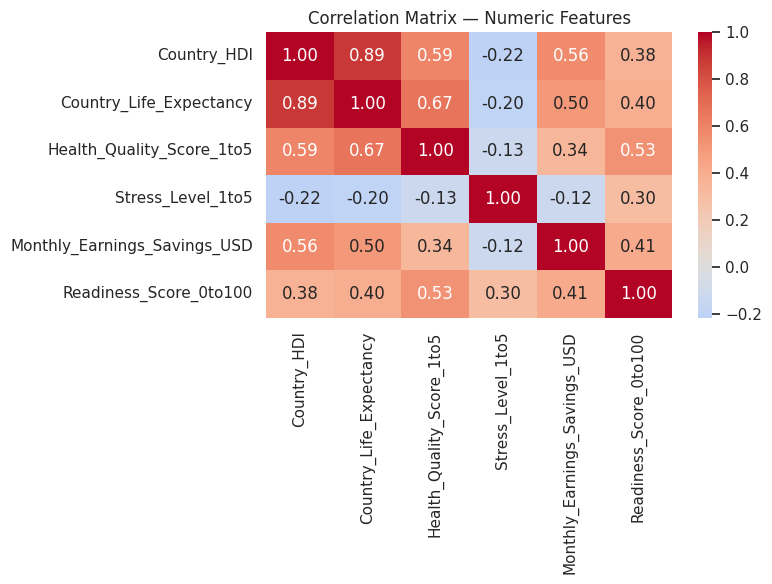

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


## 3.Numeric features vs target (scatter with trendline)

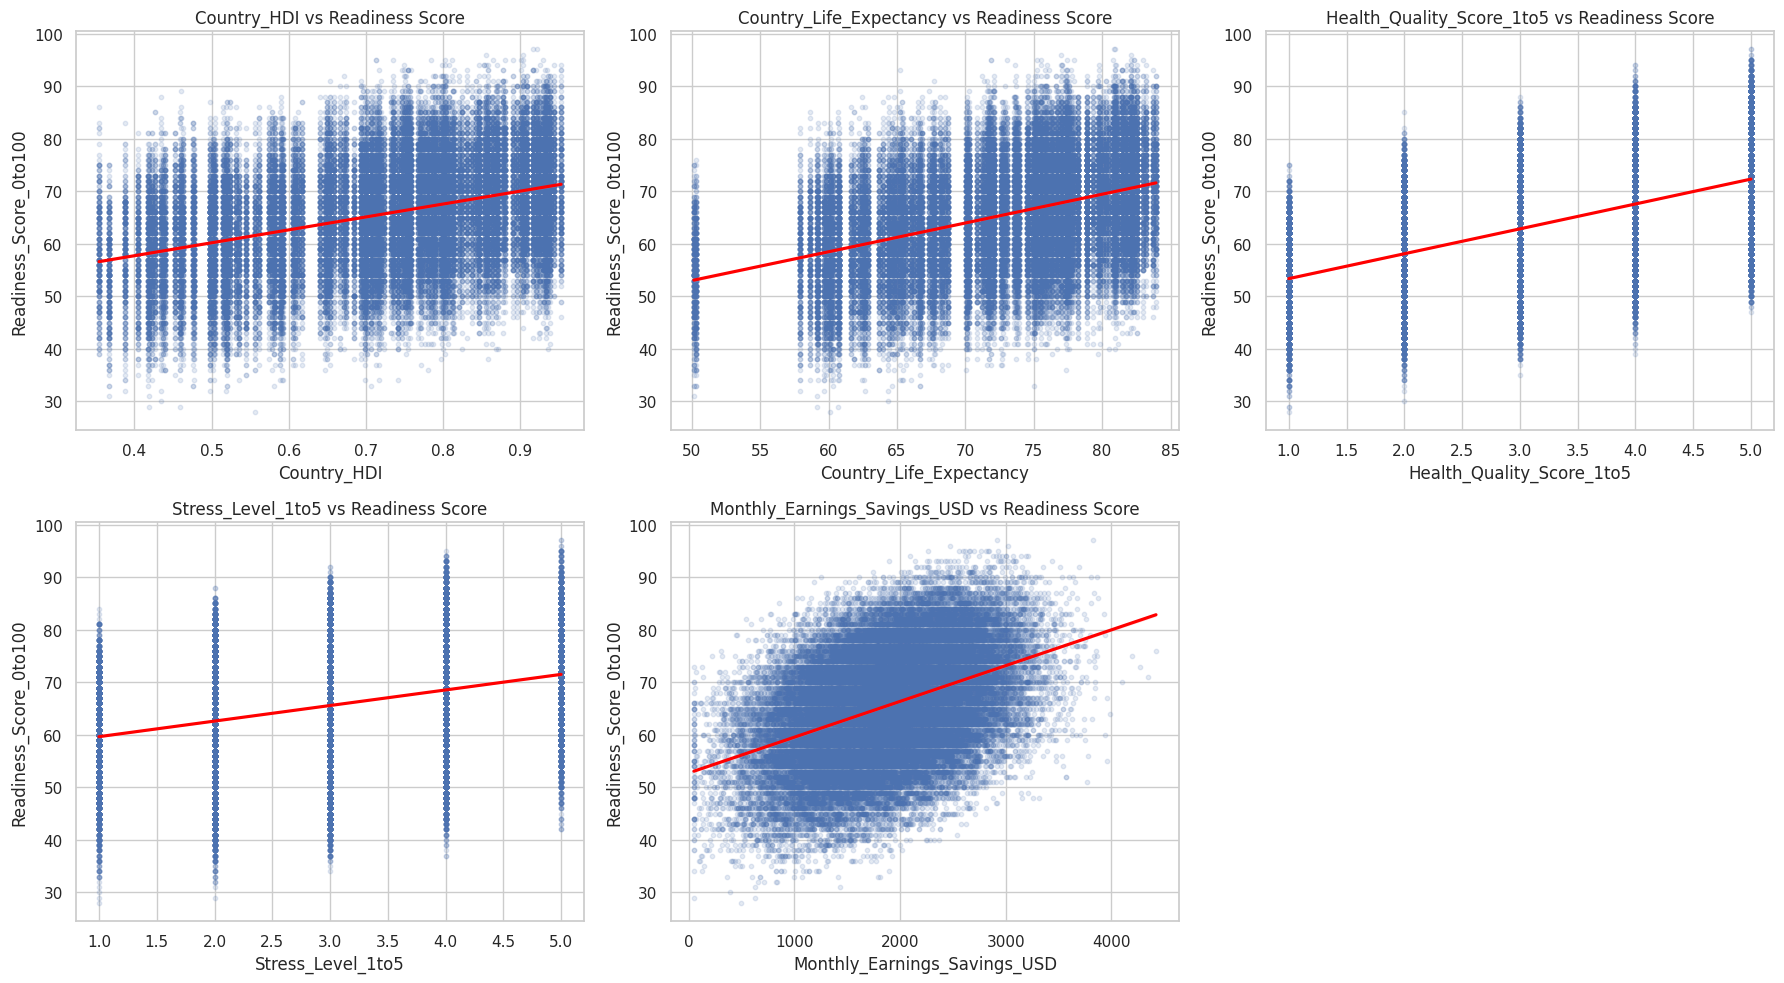

In [12]:
numeric_features = ["Country_HDI", "Country_Life_Expectancy",
                     "Health_Quality_Score_1to5", "Stress_Level_1to5",
                     "Monthly_Earnings_Savings_USD"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.regplot(data=df, x=col, y="Readiness_Score_0to100", ax=axes[i],
                scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
    axes[i].set_title(f"{col} vs Readiness Score")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 4. Categorical features vs target

/tmp/ipykernel_58/2668926400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Education_Level", y="Readiness_Score_0to100", ax=axes[0], palette="Oranges")
/tmp/ipykernel_58/2668926400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Field_of_Study", y="Readiness_Score_0to100", order=order, ax=axes[1], palette="Oranges")
/tmp/ipykernel_58/2668926400.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Language_Proficiency", y="Readiness_Score_0to100", order=lang_order, ax=axes[2], palette="Oranges")


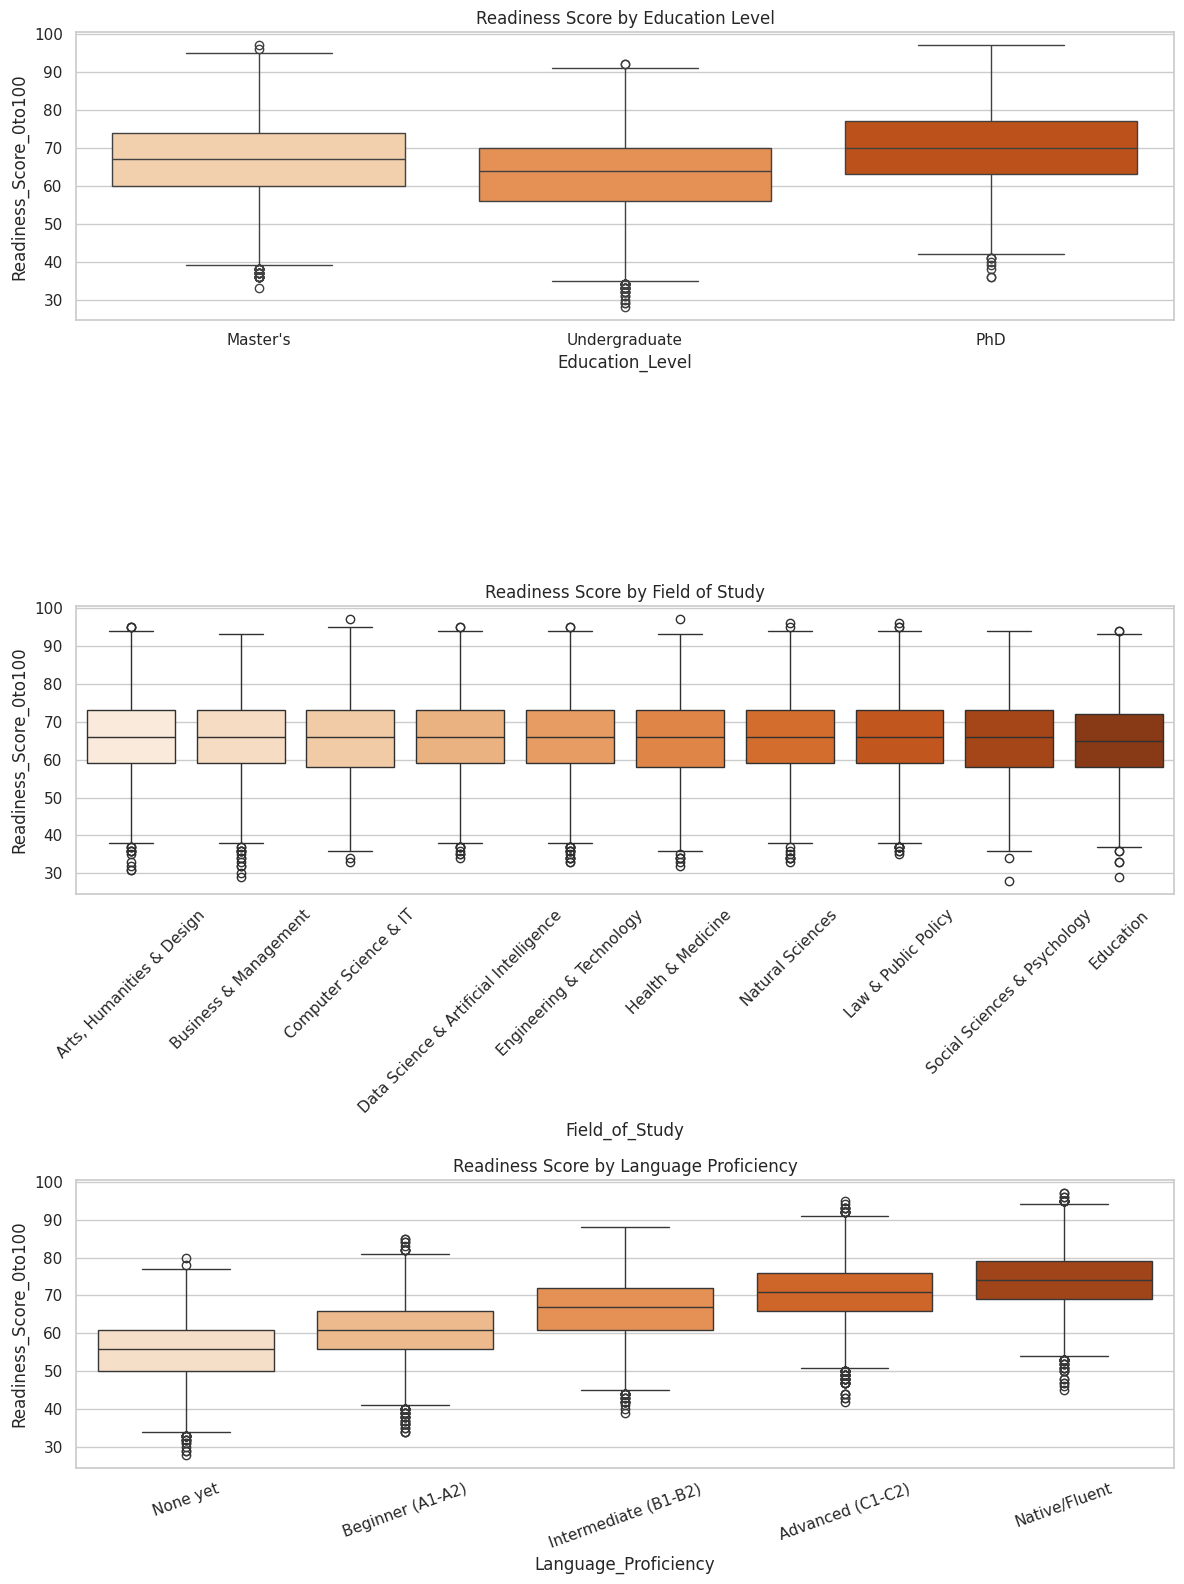

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

sns.boxplot(data=df, x="Education_Level", y="Readiness_Score_0to100", ax=axes[0], palette="Oranges")
axes[0].set_title("Readiness Score by Education Level")

order = df.groupby("Field_of_Study")["Readiness_Score_0to100"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Field_of_Study", y="Readiness_Score_0to100", order=order, ax=axes[1], palette="Oranges")
axes[1].set_title("Readiness Score by Field of Study")
axes[1].tick_params(axis="x", rotation=45)

lang_order = ["None yet", "Beginner (A1-A2)", "Intermediate (B1-B2)", "Advanced (C1-C2)", "Native/Fluent"]
sns.boxplot(data=df, x="Language_Proficiency", y="Readiness_Score_0to100", order=lang_order, ax=axes[2], palette="Oranges")
axes[2].set_title("Readiness Score by Language Proficiency")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 5. Country-level view: average readiness vs HDI (top 20 most frequent countries)

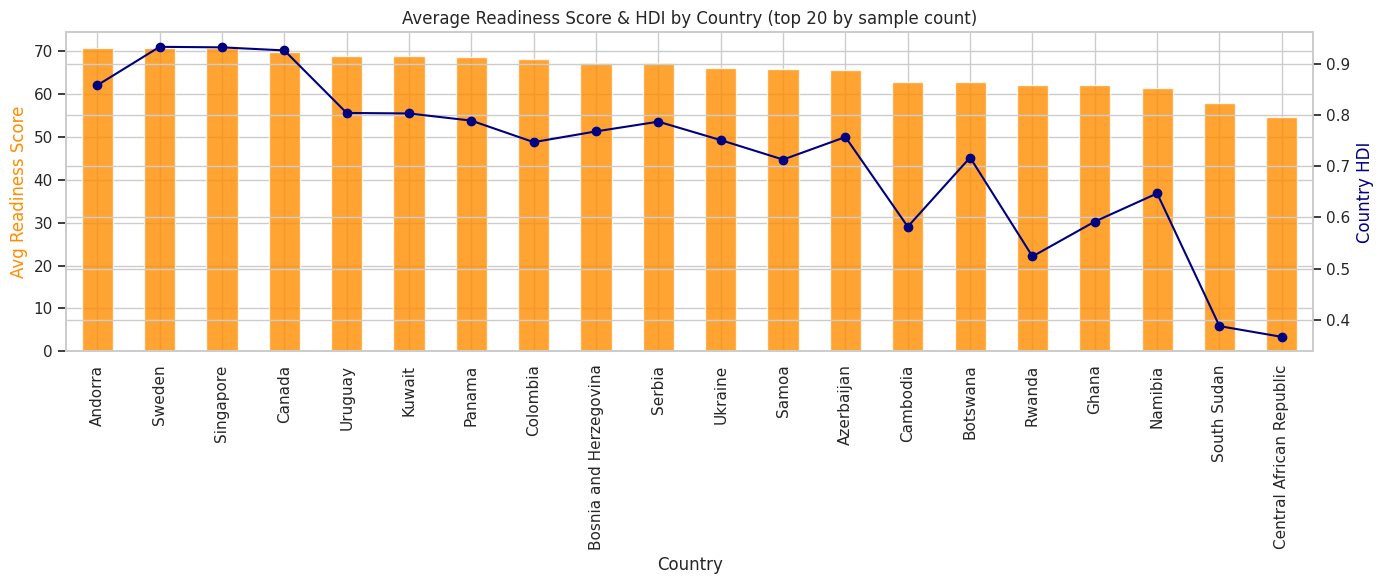

In [14]:
top_countries = df["Country"].value_counts().head(20).index
country_stats = (df[df["Country"].isin(top_countries)]
                  .groupby("Country")[["Country_HDI", "Readiness_Score_0to100"]]
                  .mean()
                  .sort_values("Readiness_Score_0to100", ascending=False))

fig, ax1 = plt.subplots(figsize=(14, 6))
country_stats["Readiness_Score_0to100"].plot(kind="bar", ax=ax1, color="darkorange", alpha=0.8)
ax1.set_ylabel("Avg Readiness Score", color="darkorange")
ax1.set_title("Average Readiness Score & HDI by Country (top 20 by sample count)")

ax2 = ax1.twinx()
ax2.plot(range(len(country_stats)), country_stats["Country_HDI"], color="navy", marker="o")
ax2.set_ylabel("Country HDI", color="navy")

plt.tight_layout()
plt.show()

# Preprocessing

## Target split

In [15]:
target = "Readiness_Score_0to100"

feature_cols = [
    "Country_HDI", "Country_Life_Expectancy",
    "Education_Level", "Field_of_Study", "Language_Proficiency",
    "Health_Quality_Score_1to5", "Stress_Level_1to5", "Monthly_Earnings_Savings_USD",
]

X = df[feature_cols].copy()
y = df[target].copy()

ordinal_features = ["Education_Level", "Language_Proficiency"]
ordinal_categories = [
    ["Undergraduate", "Master's", "PhD"],
    ["None yet", "Beginner (A1-A2)", "Intermediate (B1-B2)", "Advanced (C1-C2)", "Native/Fluent"],
]
onehot_features = ["Field_of_Study"]
numeric_features_all = ["Country_HDI", "Country_Life_Expectancy",
                         "Health_Quality_Score_1to5", "Stress_Level_1to5",
                         "Monthly_Earnings_Savings_USD"]

preprocessor = ColumnTransformer(transformers=[
    ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_features),
    ("ohe", OneHotEncoder(handle_unknown="ignore"), onehot_features),
    ("num", "passthrough", numeric_features_all),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (44000, 8)  Test shape: (11000, 8)


# Model Training & Comparison

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9,
                                 random_state=RANDOM_STATE, n_jobs=-1),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    results.append({"Model": name, "CV R2 Mean": scores.mean(), "CV R2 Std": scores.std()})
    print(f"{name:20s}  R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values("CV R2 Mean", ascending=False)
results_df

Linear Regression     R2 = 0.9824 (+/- 0.0002)
Ridge Regression      R2 = 0.9824 (+/- 0.0002)
Random Forest         R2 = 0.9834 (+/- 0.0002)
Gradient Boosting     R2 = 0.9859 (+/- 0.0002)
XGBoost               R2 = 0.9869 (+/- 0.0002)


,Model,CV R2 Mean,CV R2 Std
4,XGBoost,0.986859,0.000224
3,Gradient Boosting,0.985871,0.000232
2,Random Forest,0.983401,0.000208
1,Ridge Regression,0.982369,0.000249
0,Linear Regression,0.982369,0.000249


## Visualize model comparison

/tmp/ipykernel_58/4040676480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="CV R2 Mean", palette="Oranges_r")


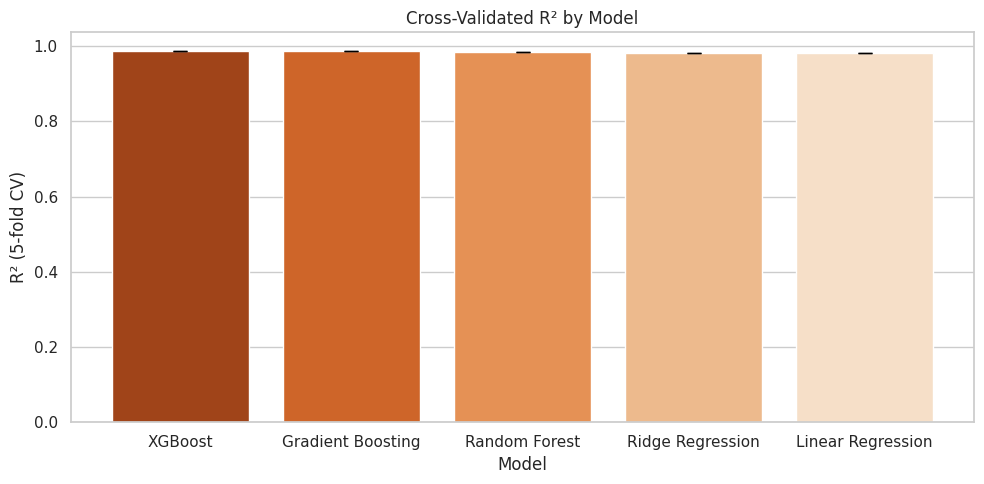

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="CV R2 Mean", palette="Oranges_r")
plt.errorbar(x=range(len(results_df)), y=results_df["CV R2 Mean"], yerr=results_df["CV R2 Std"],
             fmt="none", c="black", capsize=5)
plt.title("Cross-Validated R² by Model")
plt.ylabel("R² (5-fold CV)")
plt.tight_layout()
plt.show()


#  Final Model

In [23]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

best_model = models[best_model_name]
final_pipe = Pipeline([("prep", preprocessor), ("model", best_model)])
final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE : {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R2  : {r2:.3f}")


Best model: XGBoost
Test MAE : 0.988
Test RMSE: 1.159
Test R2  : 0.987


## Predicted vs actual

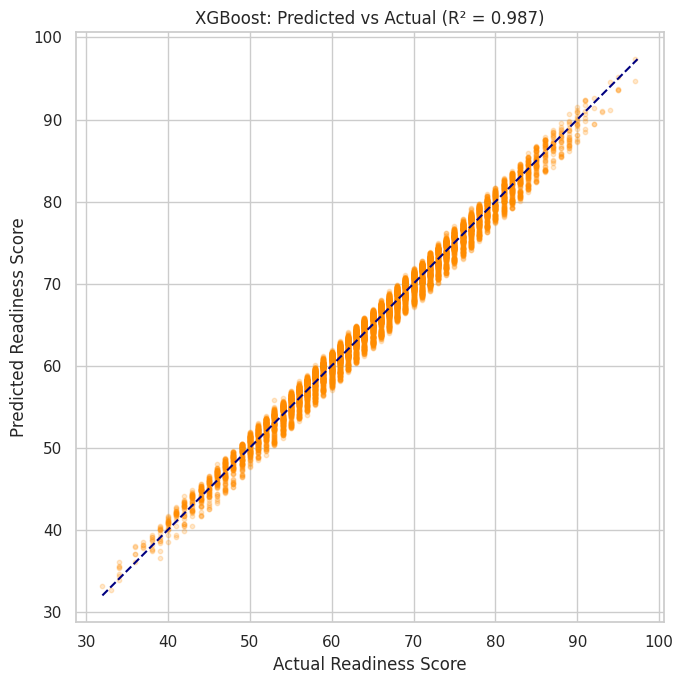

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.2, s=10, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "--", color="navy")
plt.xlabel("Actual Readiness Score")
plt.ylabel("Predicted Readiness Score")
plt.title(f"{best_model_name}: Predicted vs Actual (R² = {r2:.3f})")
plt.tight_layout()
plt.show()


##  Explainability (SHAP)

**Transform data through the preprocessor so SHAP sees the same features the model sees**

In [25]:
X_test_transformed = final_pipe.named_steps["prep"].transform(X_test)

**Get readable feature names out of the ColumnTransformer**

In [27]:
ohe_names = final_pipe.named_steps["prep"].named_transformers_["ohe"].get_feature_names_out(onehot_features)
feature_names = ordinal_features + list(ohe_names) + numeric_features_all

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

**Tree-based models -> TreeExplainer (fast, exact). Others -> generic Explainer**


In [28]:
model_step = final_pipe.named_steps["model"]
if best_model_name in ("Random Forest", "Gradient Boosting", "XGBoost"):
    explainer = shap.TreeExplainer(model_step)
else:
    explainer = shap.Explainer(model_step, X_test_df)

shap_values = explainer(X_test_df)

### Global feature importance


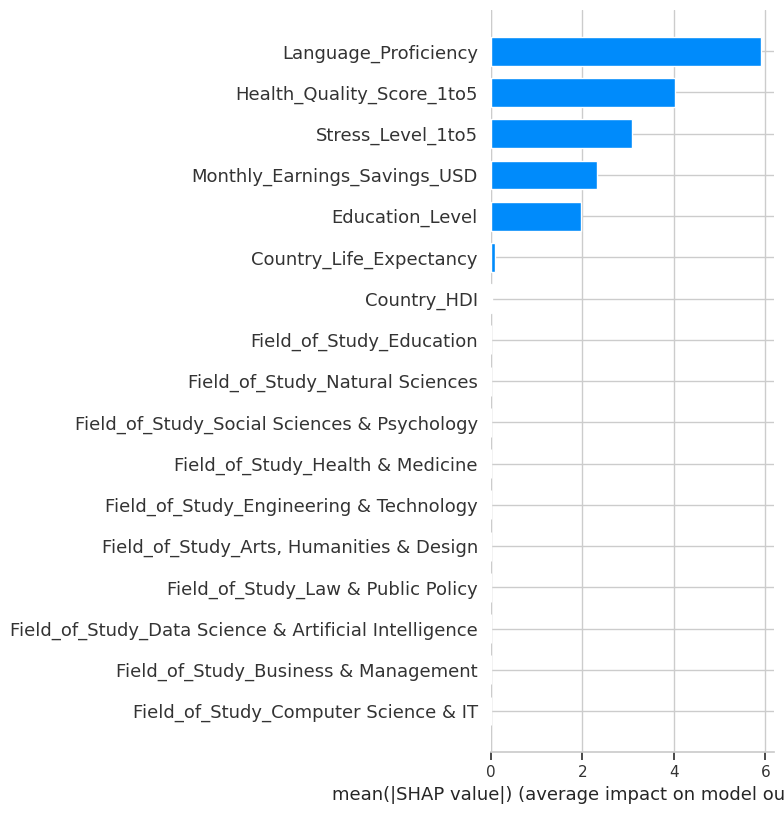

In [29]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=True)

### Global impact + direction (beeswarm)

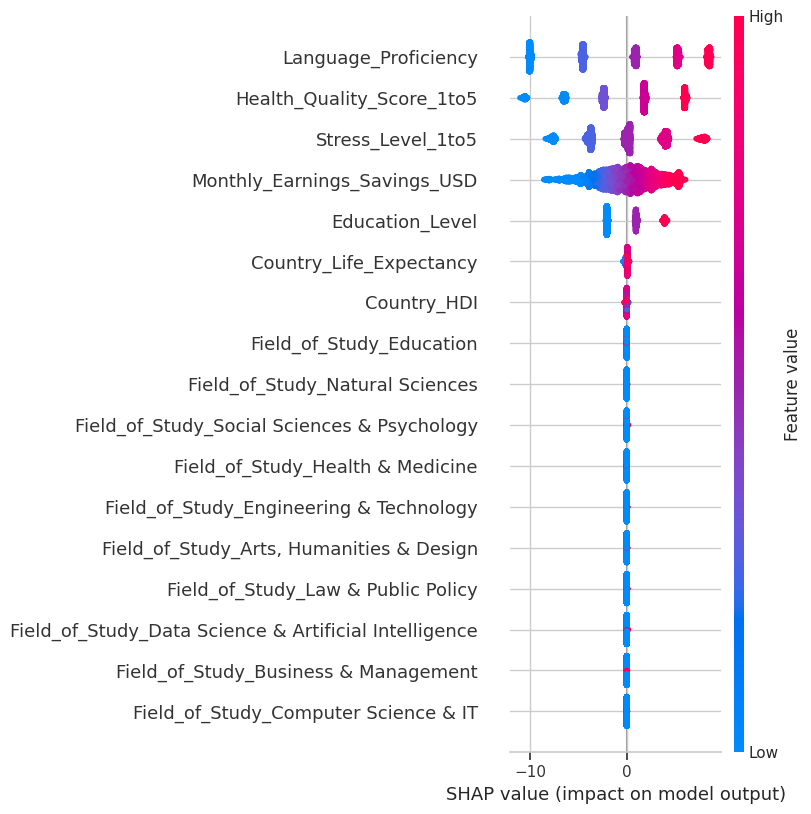

In [30]:
shap.summary_plot(shap_values, X_test_df, show=True)

# Individual prediction explanation (first test row) — this is the kind of
# "why we recommend this / your readiness is X because of Y" narrative for professional.html


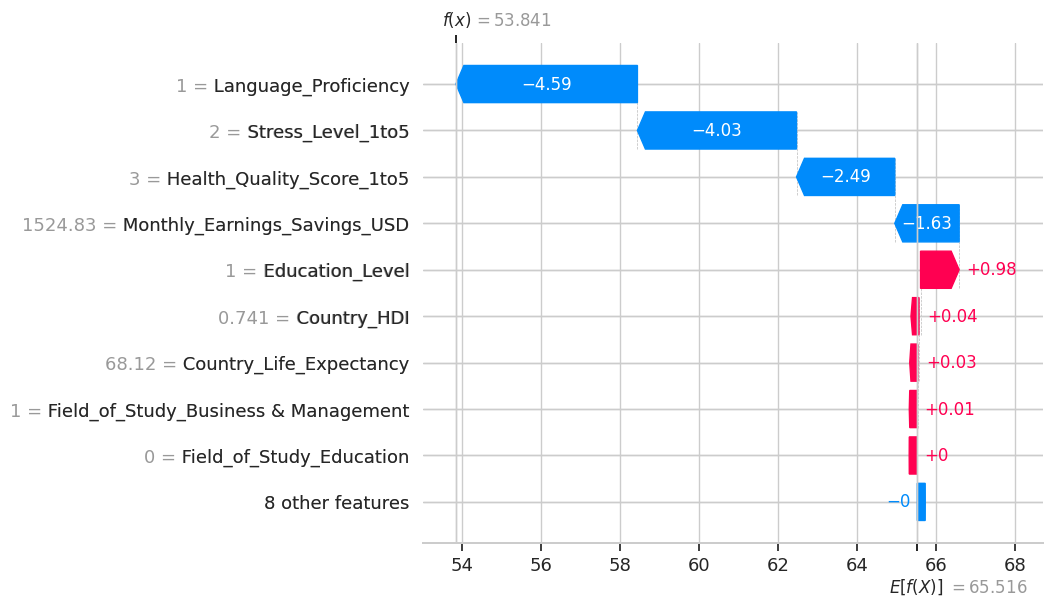

In [31]:
shap.plots.waterfall(shap_values[0], show=True)

# Save the model

In [32]:
joblib.dump(final_pipe, "/kaggle/working/readiness_model.pkl")
print("Model saved to /kaggle/working/readiness_model.pkl")

# Quick sanity check: reload and predict
reloaded = joblib.load("/kaggle/working/readiness_model.pkl")
sample_pred = reloaded.predict(X_test.iloc[:5])
print("Sample predictions:", sample_pred)
print("Actual values     :", y_test.iloc[:5].values)


Model saved to /kaggle/working/readiness_model.pkl
Sample predictions: [53.84125  57.140175 66.44135  63.215767 64.93183 ]
Actual values     : [54 59 65 62 64]
